# ASDMotion → 1D-CNN : data preparation, pre-processing evidence & data understanding

Runs top-to-bottom and produces every table and figure needed for
**4.3 Data Pre-processing** and **4.4 Data Understanding**.

* **Part A** – the preparation pipeline (instrumented to record diagnostics).
* **Part B – §4.3** – evidence for each pre-processing step.
* **Part C – §4.4** – understanding of the final prepared dataset.

All figures are written to `figures/` as PNG; all tables are pandas DataFrames
(use `.to_latex()` / `.to_markdown()` to paste into the report).

---
## Part A — Preparation pipeline

In [1]:
# ── Config ───────────────────────────────────────────────────────────
PKL_PATH     = "dataset.pkl"   # path to the ASDMotion annotated pickle
OUT_DIR      = "prepared"      # arrays + reports are written here
FIG_DIR      = "figures"       # report figures are written here
WINDOW       = 90              # frames per sample (3 s @ 30 fps)
STRIDE_TRAIN = 30              # window step for train (overlap = augmentation)
STRIDE_TEST  = 90              # non-overlapping windows for honest evaluation
MAX_GAP      = 4               # interpolate missing runs up to this many frames
MAX_INVALID  = 0.5             # drop a window if > this fraction of it is missing
MAX_SEGMENTS = None            # set to e.g. 500 for a quick dry run, else None

SAVE_FIGS      = True          # write PNGs to FIG_DIR
FIG_DPI        = 150
SAMPLE_WINDOWS = 20000         # windows sampled for heavy statistics / plots
RNG_SEED       = 0

In [2]:
# ── Imports + constants ──────────────────────────────────────────────
import os, json, csv, pickle
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": FIG_DPI, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
})
pd.set_option("display.width", 160, "display.max_columns", 40,
              "display.float_format", lambda v: f"{v:,.4g}")

POS_C, NEG_C, ACC_C = "#c0504d", "#4f81bd", "#9bbb59"   # positive / negative / accent

KP_NAMES = ["nose", "left_eye", "right_eye", "left_ear", "right_ear",
            "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
            "left_wrist", "right_wrist", "left_hip", "right_hip",
            "left_knee", "right_knee", "left_ankle", "right_ankle"]
KEEP = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
KEEP_NAMES = [KP_NAMES[i] for i in KEEP]
SHORT = [n.replace("left_", "L ").replace("right_", "R ") for n in KEEP_NAMES]
L_SH, R_SH, L_HIP, R_HIP = 5, 6, 11, 12

PURE_LOWER = {"Toe walking", "Legs movement"}   # dropped from positives
GROSS = {"Hand flapping", "Clapping", "Jumping in place", "Spinning in circle",
         "Back and forth", "Body rocking", "Head movement"}

os.makedirs(FIG_DIR, exist_ok=True)

def savefig(fig, name):
    """Save a figure into FIG_DIR and report the path."""
    if SAVE_FIGS:
        p = os.path.join(FIG_DIR, f"{name}.png")
        fig.savefig(p)
        print("figure ->", p)
    return fig

def show(df, name=None, caption=None):
    """Display a table and optionally save it as CSV for the report."""
    if caption:
        print(caption)
    if name and SAVE_FIGS:
        df.to_csv(os.path.join(FIG_DIR, f"{name}.csv"))
    display(df)
    return df

In [3]:
# ── Helper functions (instrumented) ──────────────────────────────────
def segment_scale(kp, min_frames=5):
    """Single robust scale (px) for a segment. Returns (scale, method) or (None,'fail')."""
    def real(i):
        return ~((kp[:, i, 0] == 0) & (kp[:, i, 1] == 0))

    sh = real(L_SH) & real(R_SH)
    if sh.sum() >= min_frames:
        w = np.linalg.norm(kp[sh, L_SH, :] - kp[sh, R_SH, :], axis=1)
        w = w[w > 1e-6]
        if w.size >= min_frames:
            return float(np.median(w)), "shoulder"

    hp = real(L_HIP) & real(R_HIP)
    both = sh & hp
    if both.sum() >= min_frames:
        msh = (kp[:, L_SH, :] + kp[:, R_SH, :]) / 2
        mhip = (kp[:, L_HIP, :] + kp[:, R_HIP, :]) / 2
        tor = np.linalg.norm(msh[both] - mhip[both], axis=1)
        tor = tor[tor > 1e-6]
        if tor.size >= min_frames:
            return float(np.median(tor)), "torso"

    pts = kp[:, KEEP, :]
    realk = ~((pts[..., 0] == 0) & (pts[..., 1] == 0))
    spreads = []
    for t in range(pts.shape[0]):
        m = realk[t]
        if m.sum() >= 3:
            p = pts[t, m, :]
            spreads.append(max(np.ptp(p[:, 0]), np.ptp(p[:, 1])))
    if spreads:
        s = float(np.median(spreads))
        if s > 1e-6:
            return s, "bbox"
    return None, "fail"


def interp_gaps(coords, valid, max_gap, gap_log=None):
    """Linearly fill interior gaps <= max_gap. Optionally log (length, filled)."""
    T = len(valid)
    c, v = coords.copy(), valid.copy()
    t = 0
    while t < T:
        if v[t]:
            t += 1
            continue
        s = t
        while t < T and not v[t]:
            t += 1
        e = t                       # invalid run is [s, e)
        gap = e - s
        interior = s > 0 and e < T
        filled = interior and gap <= max_gap
        if filled:
            x0, x1 = c[s - 1], c[e]
            for j in range(gap):
                a = (j + 1) / (gap + 1)
                c[s + j] = x0 * (1 - a) + x1 * a
                v[s + j] = True
        if gap_log is not None:
            gap_log.append((gap, int(filled), int(interior)))
    return c, v


def process_segment(rec, max_gap, gap_log=None):
    """-> (speed(T,10), conf(T,10), speed_valid(T,10), method, scale, T, fps) or None."""
    kp = np.asarray(rec["keypoint"], dtype=np.float64)          # (T,17,2)
    sc = np.asarray(rec["keypoint_score"], dtype=np.float64)    # (T,17)
    fps = float(rec.get("fps", 30.0))
    T = kp.shape[0]

    scale, method = segment_scale(kp)
    if scale is None:
        return None

    P = kp[:, KEEP, :]
    realk = ~((P[..., 0] == 0) & (P[..., 1] == 0))
    Pn = P / scale

    valid = realk.copy()
    for k in range(len(KEEP)):
        Pn[:, k, :], valid[:, k] = interp_gaps(Pn[:, k, :], realk[:, k], max_gap, gap_log)

    dt = 1.0 / fps
    speed = np.zeros((T, len(KEEP)), dtype=np.float64)
    both = valid[1:] & valid[:-1]
    d = np.linalg.norm(Pn[1:] - Pn[:-1], axis=2)
    speed[1:] = np.where(both, d / dt, 0.0)
    speed_valid = np.zeros((T, len(KEEP)), dtype=bool)
    speed_valid[1:] = both

    conf = np.clip(sc[:, KEEP], 0.0, 1.0)
    return speed, conf, speed_valid, method, scale, T, fps


def iter_windows(speed, conf, speed_valid, window, stride, max_invalid):
    """Yield (start, x(C,L), mean_speed, invalid_frac) for windows passing the gate."""
    T = speed.shape[0]
    if T < window:
        return
    for start in range(0, T - window + 1, stride):
        sl = slice(start, start + window)
        sv = speed_valid[sl]
        inv = 1.0 - sv.mean()
        if inv > max_invalid:
            continue
        sp, cf = speed[sl], conf[sl]
        x = np.concatenate([sp, cf], axis=1).T             # (20, L)
        ms = float(sp[sv].mean()) if sv.any() else 0.0
        yield start, x.astype(np.float32), ms, float(inv)


def subject_of(ident):
    return str(ident).split("_")[0]


def is_pure_lower(action_name, label):
    if label != 1 or not action_name:
        return False
    toks = {t.strip() for t in str(action_name).split(",")}
    return toks.issubset(PURE_LOWER)

In [4]:
# ── prepare(): full pipeline + diagnostics for the report ────────────
def prepare(pkl_path, out_dir, window=90, stride_train=30, stride_test=90,
            max_gap=4, max_invalid=0.5, max_segments=None):
    """Writes arrays/reports to out_dir, plus diagnostics.npz for §4.3 evidence."""
    os.makedirs(out_dir, exist_ok=True)
    with open(pkl_path, "rb") as f:
        obj = pickle.load(f)
    anns, split = obj["annotations"], obj["split"]

    split_of = {}
    for name, entries in split.items():
        for e in entries:
            ident = e if isinstance(e, str) else anns[int(e)].get("identifier")
            split_of[ident] = name

    L, n_sp = window, len(KEEP)
    C = 2 * n_sp
    stride = {"train": stride_train, "test": stride_test}

    freqs = np.fft.rfftfreq(L, d=1.0 / 30.0)
    BANDS = [(0.3, 1.0), (1.0, 3.0), (3.0, 6.0), (6.0, 15.0)]
    band_idx = [np.where((freqs > lo) & (freqs <= hi))[0] for lo, hi in BANDS]
    n_spec = n_sp * len(BANDS)

    def spectral(speed_block):
        s = speed_block - speed_block.mean(0, keepdims=True)
        power = np.abs(np.fft.rfft(s, axis=0)) ** 2
        feats = np.stack([power[idx].sum(0) for idx in band_idx], axis=1)
        return np.log1p(feats).ravel().astype(np.float32)

    def category(label, action):
        if label == 0:
            return 0
        toks = {t.strip() for t in str(action).split(",")}
        return 1 if (toks & GROSS) else 2

    counts = defaultdict(int)
    meta = {"train": [], "test": []}
    dropped = defaultdict(int)
    sub = [[] for _ in range(n_sp)]           # raw (pre-clip) speed samples
    segs = anns if max_segments is None else anns[:max_segments]
    rng = np.random.default_rng(RNG_SEED)

    # diagnostics collected during pass 1 --------------------------------
    D = {"scale_method": [], "scale_px": [], "seg_frames": [], "seg_fps": [],
         "seg_split": [], "seg_label": [], "seg_windows": [], "gap_runs": []}

    for rec in segs:
        ident = rec.get("identifier"); sp_name = split_of.get(ident)
        if sp_name is None:
            dropped["not_in_split"] += 1; continue
        label = int(rec.get("binary_label", 0)); action = rec.get("action_name", "")
        if is_pure_lower(action, label):
            dropped["pure_lower_body"] += 1; continue
        gap_log = []
        out = process_segment(rec, max_gap, gap_log)
        if out is None:
            dropped["scale_fail"] += 1; continue
        speed, conf, sv, method, scale_px, T, fps = out
        D["scale_method"].append(method); D["scale_px"].append(scale_px)
        D["seg_frames"].append(T); D["seg_fps"].append(fps)
        D["seg_split"].append(sp_name); D["seg_label"].append(label)
        D["gap_runs"].extend(gap_log)

        subj = subject_of(ident); wins = 0
        cat0 = category(label, action)
        for start, x, ms, inv in iter_windows(speed, conf, sv, L,
                                              stride[sp_name], max_invalid):
            counts[sp_name] += 1; wins += 1
            meta[sp_name].append((ident, subj, action, label, cat0, start, ms, inv))
            if sp_name == "train" and rng.random() < 0.10:
                sb = x[:n_sp].T; vm = sv[start:start + L]
                for k in range(n_sp):
                    col = sb[:, k][vm[:, k]]
                    if col.size:
                        sub[k].append(col)
        D["seg_windows"].append(wins)
        if wins == 0:
            dropped["no_valid_window"] += 1
    if counts["train"] == 0:
        raise RuntimeError("No training windows produced.")

    # robust scaling statistics (train only) -----------------------------
    med = np.zeros(n_sp); iqr = np.ones(n_sp); cap = np.full(n_sp, np.inf)
    raw_keep = []                                    # raw sample kept for figures
    for k in range(n_sp):
        if sub[k]:
            v = np.concatenate(sub[k])
            if v.size > 300000:
                v = rng.choice(v, 300000, replace=False)
            med[k] = np.median(v)
            iqr[k] = max(np.percentile(v, 75) - np.percentile(v, 25), 1e-6)
            cap[k] = np.percentile(v, 99.5)
            raw_keep.append(rng.choice(v, min(v.size, 30000), replace=False))
        else:
            raw_keep.append(np.zeros(0))

    def alloc(name, n):
        mk = lambda nm, dt, sh: np.lib.format.open_memmap(
            os.path.join(out_dir, f"{nm}_{name}.npy"), mode="w+", dtype=dt, shape=sh)
        return (mk("X", np.float32, (n, C, L)), mk("y", np.int8, (n,)),
                mk("mask", np.uint8, (n, L, n_sp)), mk("F", np.float32, (n, n_spec)),
                mk("cat", np.int8, (n,)))
    handles = {nm: alloc(nm, counts[nm]) for nm in ("train", "test") if counts[nm]}
    idx = {nm: 0 for nm in handles}
    f_sum = np.zeros(n_spec); f_sqr = np.zeros(n_spec); f_cnt = 0
    n_clipped = np.zeros(n_sp); n_total = np.zeros(n_sp)

    for rec in segs:
        ident = rec.get("identifier"); sp_name = split_of.get(ident)
        if sp_name is None: continue
        label = int(rec.get("binary_label", 0)); action = rec.get("action_name", "")
        if is_pure_lower(action, label): continue
        out = process_segment(rec, max_gap)
        if out is None: continue
        speed, conf, sv, method, scale_px, T, fps = out
        if sp_name not in handles: continue
        X, y, M, F, CAT = handles[sp_name]
        cat0 = category(label, action)
        for start, x, ms, inv in iter_windows(speed, conf, sv, L,
                                              stride[sp_name], max_invalid):
            x = x.copy()
            sp_norm = x[:n_sp].T
            fvec = spectral(sp_norm)
            if sp_name == "train":                       # clipping audit
                n_clipped += (x[:n_sp] > cap[:, None]).sum(1)
                n_total += x.shape[1]
            x[:n_sp] = ((np.minimum(x[:n_sp], cap[:, None]) - med[:, None]) / iqr[:, None])
            i = idx[sp_name]
            X[i] = x; y[i] = label; M[i] = sv[start:start + L].astype(np.uint8)
            F[i] = fvec; CAT[i] = cat0
            if sp_name == "train":
                f_sum += fvec; f_sqr += fvec ** 2; f_cnt += 1
            idx[sp_name] = i + 1

    f_mean = f_sum / max(f_cnt, 1)
    f_std = np.sqrt(np.maximum(f_sqr / max(f_cnt, 1) - f_mean ** 2, 1e-8))
    for nm in handles:
        F = handles[nm][3]
        F[:] = (F[:] - f_mean) / f_std
        for h in handles[nm]:
            h.flush()

    for nm in meta:
        if not meta[nm]: continue
        with open(os.path.join(out_dir, f"meta_{nm}.csv"), "w", newline="") as f:
            w = csv.writer(f); w.writerow(
                ["identifier", "subject", "action_name", "label", "cat",
                 "window_start", "mean_speed", "invalid_frac"])
            w.writerows(meta[nm])

    spec_names = [f"band{b}_{n}" for n in KEEP_NAMES for b in range(len(BANDS))]
    with open(os.path.join(out_dir, "channels.json"), "w") as f:
        json.dump({"layout": "(N,C,L) Conv1d-ready", "C": C, "L": L, "n_spec": n_spec,
                   "kept_keypoints": KEEP_NAMES,
                   "channels": [f"speed_{n}" for n in KEEP_NAMES]
                               + [f"conf_{n}" for n in KEEP_NAMES],
                   "spectral_bands_hz": BANDS, "spectral_features": spec_names,
                   "cat_codes": {"0": "NoAction", "1": "gross-motor pos",
                                 "2": "fine-motor pos"},
                   "speed_scaling": "clip@p99.5 then (x-median)/IQR (robust)"}, f, indent=2)
    with open(os.path.join(out_dir, "scaler.json"), "w") as f:
        json.dump({"speed_median": med.tolist(), "speed_iqr": iqr.tolist(),
                   "speed_cap": cap.tolist(), "spec_mean": f_mean.tolist(),
                   "spec_std": f_std.tolist(), "keypoints": KEEP_NAMES}, f, indent=2)

    # diagnostics for the report ----------------------------------------
    gr = np.asarray(D["gap_runs"], dtype=np.int32).reshape(-1, 3)
    np.savez_compressed(
        os.path.join(out_dir, "diagnostics.npz"),
        scale_px=np.asarray(D["scale_px"], float),
        scale_method=np.asarray(D["scale_method"], object),
        seg_frames=np.asarray(D["seg_frames"], int),
        seg_fps=np.asarray(D["seg_fps"], float),
        seg_split=np.asarray(D["seg_split"], object),
        seg_label=np.asarray(D["seg_label"], int),
        seg_windows=np.asarray(D["seg_windows"], int),
        gap_len=gr[:, 0], gap_filled=gr[:, 1], gap_interior=gr[:, 2],
        raw_speed=np.concatenate([np.stack([np.full(v.size, k), v]) for k, v
                                  in enumerate(raw_keep) if v.size], axis=1)
                  if any(v.size for v in raw_keep) else np.zeros((2, 0)),
        clip_frac=np.divide(n_clipped, np.maximum(n_total, 1)),
        allow_pickle=True)

    n_pos = sum(1 for r in meta["train"] if r[3] == 1)
    n_gross = sum(1 for r in meta["train"] if r[4] == 1)
    n_fine = sum(1 for r in meta["train"] if r[4] == 2)
    n_neg = counts["train"] - n_pos
    config = {"window": L, "stride_train": stride_train, "stride_test": stride_test,
              "max_gap": max_gap, "max_invalid": max_invalid,
              "n_train": counts["train"], "n_test": counts.get("test", 0),
              "train_neg": n_neg, "train_pos": n_pos,
              "train_gross_pos": n_gross, "train_fine_pos": n_fine,
              "pos_weight_v1": round(n_neg / max(n_pos, 1), 3),
              "pos_weight_v2": round(n_neg / max(n_gross, 1), 3),
              "dropped": dict(dropped)}
    with open(os.path.join(out_dir, "train_config.json"), "w") as f:
        json.dump(config, f, indent=2)

    lines = ["ASDMotion prep — quality report", "=" * 50,
             f"windows  train={counts['train']}  test={counts.get('test',0)}",
             f"train neg={n_neg} pos={n_pos} (gross={n_gross}, fine={n_fine})",
             f"pos_weight  V1={config['pos_weight_v1']}  V2={config['pos_weight_v2']}",
             f"dropped: {dict(dropped)}", ""]
    for lab in (0, 1):
        rows = [r for r in meta["train"] if r[3] == lab]
        if rows:
            lines.append(f"label {lab}: median invalid_frac="
                         f"{np.median([r[7] for r in rows]):.3f}")
    report = "\n".join(lines)
    with open(os.path.join(out_dir, "quality_report.txt"), "w") as f:
        f.write(report + "\n")
    return {"report": report, "config": config}

In [5]:
# ── Run prep + load everything the report cells need ─────────────────
res = prepare(PKL_PATH, OUT_DIR, WINDOW, STRIDE_TRAIN, STRIDE_TEST,
              MAX_GAP, MAX_INVALID, MAX_SEGMENTS)
print(res["report"])

CH   = json.load(open(f"{OUT_DIR}/channels.json"))
SCAL = json.load(open(f"{OUT_DIR}/scaler.json"))
CFG  = json.load(open(f"{OUT_DIR}/train_config.json"))
DIAG = np.load(f"{OUT_DIR}/diagnostics.npz", allow_pickle=True)

def load(split):
    return dict(
        X=np.load(f"{OUT_DIR}/X_{split}.npy", mmap_mode="r"),
        y=np.load(f"{OUT_DIR}/y_{split}.npy"),
        cat=np.load(f"{OUT_DIR}/cat_{split}.npy"),
        F=np.load(f"{OUT_DIR}/F_{split}.npy", mmap_mode="r"),
        mask=np.load(f"{OUT_DIR}/mask_{split}.npy", mmap_mode="r"),
        meta=pd.read_csv(f"{OUT_DIR}/meta_{split}.csv"))

train, test = load("train"), load("test")
N_SP, L = len(KEEP), CH["L"]
MED = np.array(SCAL["speed_median"]); IQR = np.array(SCAL["speed_iqr"])
CAP = np.array(SCAL["speed_cap"])
rng = np.random.default_rng(RNG_SEED)

def sample_idx(d, n=SAMPLE_WINDOWS):
    N = d["X"].shape[0]
    return np.sort(rng.choice(N, min(n, N), replace=False))

TR_IDX = sample_idx(train)
Xs = np.asarray(train["X"][TR_IDX])          # (n,20,L) scaled sample
ys = train["y"][TR_IDX]
SPD, CNF = Xs[:, :N_SP, :], Xs[:, N_SP:, :]  # scaled speed / confidence
SPD_BL = SPD * IQR[None, :, None] + MED[None, :, None]   # back to body-lengths/s
print("sampled", Xs.shape[0], "train windows for figures")

ASDMotion prep — quality report
windows  train=208130  test=11932
train neg=151429 pos=56701 (gross=24566, fine=32135)
pos_weight  V1=2.671  V2=6.164
dropped: {'no_valid_window': 3251, 'scale_fail': 3371, 'pure_lower_body': 395}

label 0: median invalid_frac=0.109
label 1: median invalid_frac=0.100
sampled 20000 train windows for figures


---
## Pre-processing diagrams

The figures below illustrate the pre-processing decisions described in the report.
Each is saved to `figures/` as a PNG. They are produced from the prepared arrays
and the diagnostics recorded during `prepare()`, so every figure reflects the
actual run rather than an illustration.

### 1. Key point selection — composition of the SMM class

Among the segments labelled as containing an SMM, this shows the proportion whose
movement is expressed **exclusively through the lower body** (toe walking, leg
movements) and is therefore excluded from the positive class, versus SMMs that
involve the upper body and are retained. This motivates keeping the 10 upper-body
key points.

figure -> figures/f1_keypoint_selection_smm_pie.png


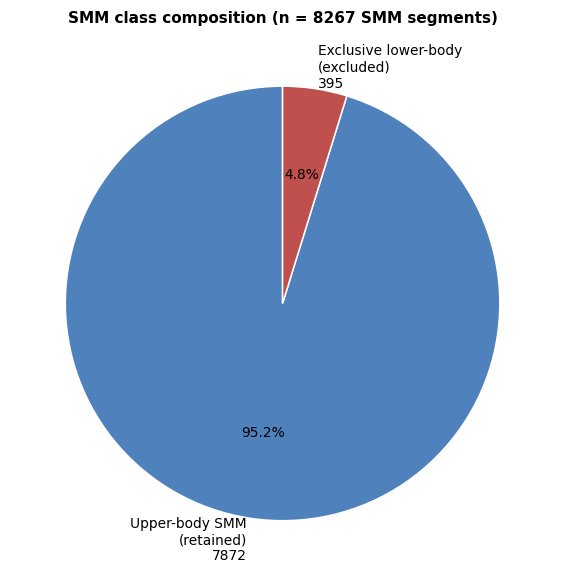

exclusive lower-body SMM: 395/8267 (4.78%)


In [6]:
# SMM segments only: exclusive lower-body vs upper-body-involving
seg = pd.concat([train["meta"], test["meta"]], ignore_index=True)
seg_smm = seg[seg["label"] == 1].drop_duplicates("identifier")

def is_excl_lower(action):
    toks = {t.strip() for t in str(action).split(",") if t.strip()}
    return bool(toks) and toks.issubset(PURE_LOWER)

# meta only contains RETAINED windows, so exclusive-lower-body segments (which are
# dropped entirely) are counted from the source diagnostics instead.
# Reconstruct counts from the full annotation pass recorded in DIAG.
lab = DIAG["seg_label"]; 
# DIAG has one row per PROCESSED segment (label kept). Exclusive-lower were dropped
# before processing, so recount them directly from the pickle for an exact figure.
import pickle as _pk
with open(PKL_PATH, "rb") as _f:
    _ann = _pk.load(_f)["annotations"]
n_excl_lower = sum(1 for r in _ann
                   if int(r.get("binary_label", 0)) == 1 and is_excl_lower(r.get("action_name", "")))
n_smm_total  = sum(1 for r in _ann if int(r.get("binary_label", 0)) == 1)
n_upper_smm  = n_smm_total - n_excl_lower

vals = [n_upper_smm, n_excl_lower]
labels = [f"Upper-body SMM\n(retained)\n{n_upper_smm}",
          f"Exclusive lower-body\n(excluded)\n{n_excl_lower}"]

fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.pie(vals, labels=labels, autopct="%1.1f%%", startangle=90,
       colors=["#4f81bd", "#c0504d"], wedgeprops=dict(edgecolor="white"))
ax.set_title(f"SMM class composition (n = {n_smm_total} SMM segments)", weight="bold")
fig.tight_layout(); savefig(fig, "f1_keypoint_selection_smm_pie"); plt.show()

print(f"exclusive lower-body SMM: {n_excl_lower}/{n_smm_total} "
      f"({100*n_excl_lower/max(n_smm_total,1):.2f}%)")

### 2. Missing key point handling

Every missing run of key points is classified into one of four cases: short interior
gaps of at most `MAX_GAP` frames, which are **interpolated**; longer interior gaps,
which remain invalid; and **edge gaps** at the start or end of a segment, which have
no surrounding values and cannot be interpolated. The count of fully-valid
(no-missing) key-point tracks is shown alongside for context.

figure -> figures/f2_missing_keypoints_bar.png


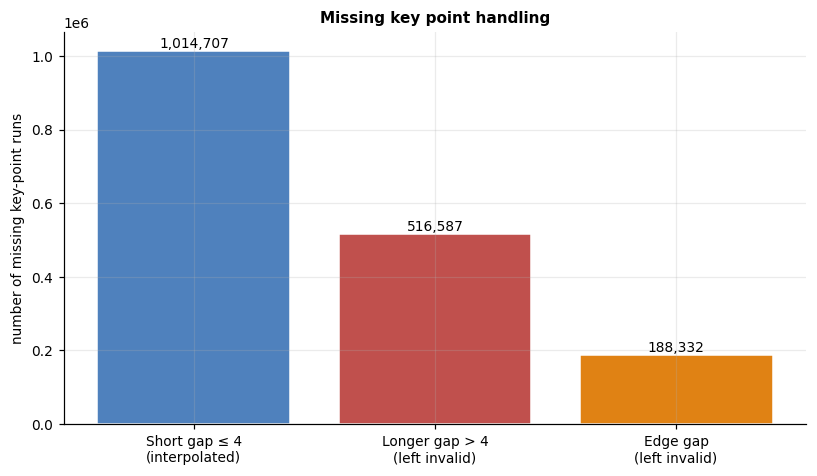

interpolated: 1,014,707 (59.0% of gaps)
left invalid (long): 516,587 | edge: 188,332


In [7]:
gl, gf, gi = DIAG["gap_len"], DIAG["gap_filled"], DIAG["gap_interior"]

n_short_filled  = int(((gi == 1) & (gf == 1)).sum())       # interior, <= MAX_GAP -> interpolated
n_long_interior = int(((gi == 1) & (gf == 0)).sum())       # interior, > MAX_GAP -> stays invalid
n_edge          = int((gi == 0).sum())                     # start/end gaps -> stays invalid

cats = [f"Short gap ≤ {MAX_GAP}\n(interpolated)",
        f"Longer gap > {MAX_GAP}\n(left invalid)",
        "Edge gap\n(left invalid)"]
counts = [n_short_filled, n_long_interior, n_edge]
colors = ["#4f81bd", "#c0504d", "#e08214"]

fig, ax = plt.subplots(figsize=(7.5, 4.4))
bars = ax.bar(cats, counts, color=colors, edgecolor="white")
ax.set_ylabel("number of missing key-point runs")
ax.set_title("Missing key point handling", weight="bold")
for b, c in zip(bars, counts):
    ax.text(b.get_x()+b.get_width()/2, c, f"{c:,}", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=.25)
fig.tight_layout(); savefig(fig, "f2_missing_keypoints_bar"); plt.show()

tot_gaps = n_short_filled + n_long_interior + n_edge
print(f"interpolated: {n_short_filled:,} ({100*n_short_filled/max(tot_gaps,1):.1f}% of gaps)")
print(f"left invalid (long): {n_long_interior:,} | edge: {n_edge:,}")

### 3. Window-level missing-data rejection

After interpolation, each 90-frame window is accepted or rejected according to
whether more than `MAX_INVALID` (50%) of its values remain invalid. Rejection is
applied per window rather than per segment, so a segment with an isolated bad
region can still contribute its valid windows.

figure -> figures/f3_window_rejection_bar.png


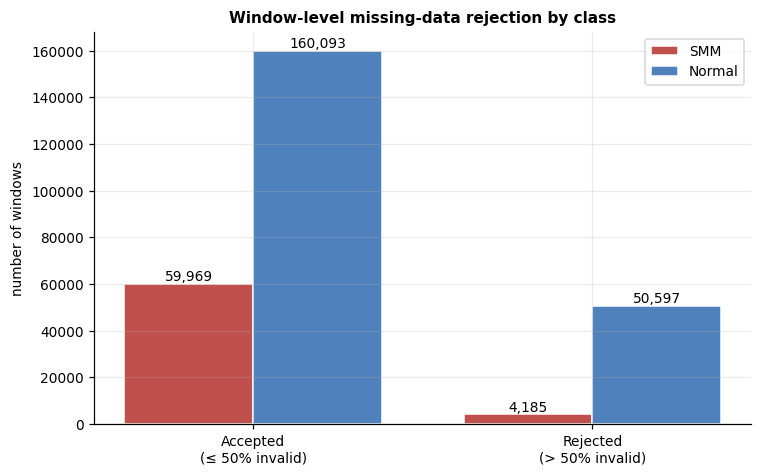

SMM     — accepted 59,969  rejected 4,185
Normal  — accepted 160,093  rejected 50,597
total windows 274,844 | overall rejected 19.9%


In [8]:
# meta holds only RETAINED windows; rejected ones are recomputed by re-walking.
# Each window inherits its parent SEGMENT's label, so "SMM window" = a window from
# an SMM-labelled segment. We split both accepted and rejected by that class.
import pickle as _pk
with open(PKL_PATH, "rb") as _f:
    _obj = _pk.load(_f)
_ann, _split = _obj["annotations"], _obj["split"]
_split_of = {}
for _n, _es in _split.items():
    for _e in _es:
        _split_of[_e if isinstance(_e, str) else _ann[int(_e)].get("identifier")] = _n

# counts[label][accepted?]  -> label 0 = normal, 1 = SMM
acc = {0: 0, 1: 0}      # accepted windows per class
rej = {0: 0, 1: 0}      # rejected windows per class
for _rec in (_ann if MAX_SEGMENTS is None else _ann[:MAX_SEGMENTS]):
    _sp = _split_of.get(_rec.get("identifier"))
    if _sp is None:
        continue
    _label = int(_rec.get("binary_label", 0))
    if is_pure_lower(_rec.get("action_name", ""), _label):
        continue
    _out = process_segment(_rec, MAX_GAP)
    if _out is None:
        continue
    _speed, _conf, _sv, _m, _s, _T, _fps = _out
    _stride = STRIDE_TRAIN if _sp == "train" else STRIDE_TEST
    if _T >= WINDOW:
        for _st in range(0, _T - WINDOW + 1, _stride):
            invalid_frac = 1.0 - _sv[_st:_st + WINDOW].mean()
            if invalid_frac > MAX_INVALID:
                rej[_label] += 1
            else:
                acc[_label] += 1

# grouped bars: SMM vs Normal, accepted vs rejected
groups = ["Accepted\n(≤ 50% invalid)", "Rejected\n(> 50% invalid)"]
smm_vals    = [acc[1], rej[1]]
normal_vals = [acc[0], rej[0]]

x = np.arange(len(groups)); w = 0.38
fig, ax = plt.subplots(figsize=(7.0, 4.4))
b1 = ax.bar(x - w/2, smm_vals,    w, label="SMM",    color="#c0504d", edgecolor="white")
b2 = ax.bar(x + w/2, normal_vals, w, label="Normal", color="#4f81bd", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel("number of windows")
ax.set_title("Window-level missing-data rejection by class", weight="bold")
ax.legend()
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                f"{int(b.get_height()):,}", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=.25)
fig.tight_layout(); savefig(fig, "f3_window_rejection_bar"); plt.show()

tot = sum(acc.values()) + sum(rej.values())
print(f"SMM     — accepted {acc[1]:,}  rejected {rej[1]:,}")
print(f"Normal  — accepted {acc[0]:,}  rejected {rej[0]:,}")
print(f"total windows {tot:,} | overall rejected "
      f"{100*(rej[0]+rej[1])/max(tot,1):.1f}%")

### 4. Outlier clipping and robust standardization

The effect of clipping at the 99.5th percentile and standardizing by the median
and IQR. The left panel shows the **raw** per-key-point speed distribution before
treatment; the right panel shows the same channels **after** clipping and robust
scaling. Outliers are compressed and the channels are brought onto a common scale.

figure -> figures/f4_outlier_scaling_boxplots.png


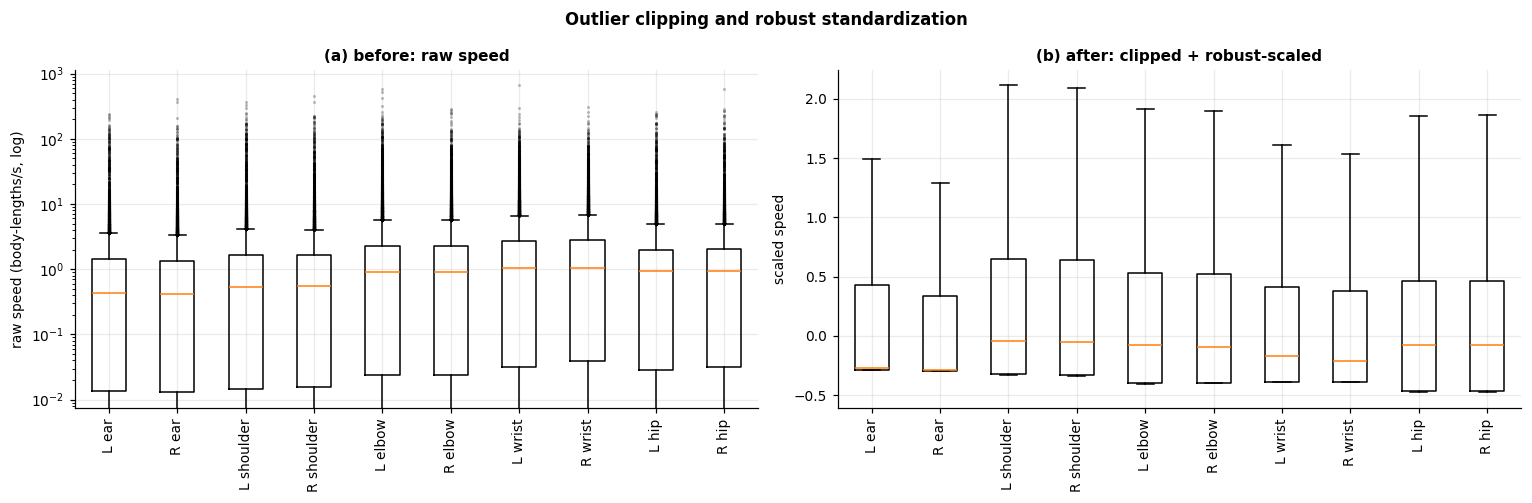

In [9]:
raw = DIAG["raw_speed"]                    # (2, M): row0 keypoint idx, row1 raw speed
raw_k, raw_v = raw[0].astype(int), raw[1]
short = [n.replace("left_","L ").replace("right_","R ") for n in KEEP_NAMES]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

# (a) raw
ax[0].boxplot([raw_v[raw_k == k] for k in range(N_SP)], showfliers=True,
              flierprops=dict(ms=1, alpha=.25))
ax[0].set_yscale("log")
ax[0].set_xticks(range(1, N_SP+1)); ax[0].set_xticklabels(short, rotation=90)
ax[0].set(ylabel="raw speed (body-lengths/s, log)", title="(a) before: raw speed")

# (b) after clip + robust scale
ax[1].boxplot([SPD[:, k, :].ravel() for k in range(N_SP)], showfliers=False)
ax[1].set_xticks(range(1, N_SP+1)); ax[1].set_xticklabels(short, rotation=90)
ax[1].set(ylabel="scaled speed", title="(b) after: clipped + robust-scaled")

fig.suptitle("Outlier clipping and robust standardization", weight="bold")
fig.tight_layout(); savefig(fig, "f4_outlier_scaling_boxplots"); plt.show()

### 5. Data understanding — Variables

The structure of the prepared data presented to the model. No figure; the table
documents each array and its meaning.

In [10]:
var_tbl = pd.DataFrame([
    ("X[:, 0:10, :]", "float32", "(N, 10, 90)", "standardized speed, 10 key points × 90 frames"),
    ("X[:, 10:20, :]", "float32", "(N, 10, 90)", "key point detection confidence, 0–1"),
    ("y", "int8", "(N,)", "target: 1 if the window contains an SMM, else 0"),
    ("cat", "int8", "(N,)", "0 = no action, 1 = gross-motor SMM, 2 = fine-motor SMM"),
    ("F", "float32", "(N, 40)", "spectral band energies (4 bands × 10 key points), z-scored"),
    ("mask", "uint8", "(N, 90, 10)", "per-frame speed validity, 1 = valid"),
], columns=["variable", "dtype", "shape", "description"]).set_index("variable")
show(var_tbl, "t5_variables", "Table — variable structure of the prepared dataset")

Table — variable structure of the prepared dataset


,dtype,shape,description
variable,,,
"X[:, 0:10, :]",float32,"(N, 10, 90)","standardized speed, 10 key points × 90 frames"
"X[:, 10:20, :]",float32,"(N, 10, 90)","key point detection confidence, 0–1"
y,int8,"(N,)","target: 1 if the window contains an SMM, else 0"
cat,int8,"(N,)","0 = no action, 1 = gross-motor SMM, 2 = fine-m..."
F,float32,"(N, 40)",spectral band energies (4 bands × 10 key point...
mask,uint8,"(N, 90, 10)","per-frame speed validity, 1 = valid"


,dtype,shape,description
variable,,,
"X[:, 0:10, :]",float32,"(N, 10, 90)","standardized speed, 10 key points × 90 frames"
"X[:, 10:20, :]",float32,"(N, 10, 90)","key point detection confidence, 0–1"
y,int8,"(N,)","target: 1 if the window contains an SMM, else 0"
cat,int8,"(N,)","0 = no action, 1 = gross-motor SMM, 2 = fine-m..."
F,float32,"(N, 40)",spectral band energies (4 bands × 10 key point...
mask,uint8,"(N, 90, 10)","per-frame speed validity, 1 = valid"


### 6. Data understanding — Observations

Two views of how the two classes differ in the prepared data. The left panel shows
the **mean temporal profile**: the average standardized speed at each frame within a
window, for SMM and no-action windows. The right panel shows the **mean spectral band
energy** per frequency band. SMM windows are expected to show higher, more sustained
speed and elevated energy in the rocking / hand-flapping bands.

figure -> figures/f6_observations.png


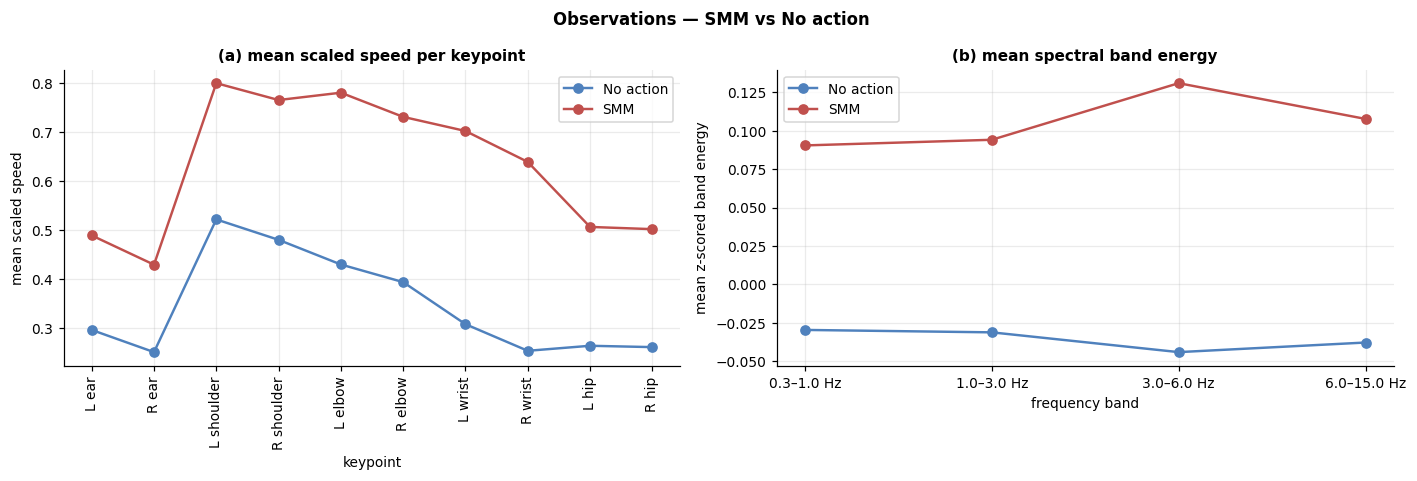

In [12]:
POS_C, NEG_C = "#c0504d", "#4f81bd"

# sampled arrays: SPD (n,10,L) scaled speed, ys labels; F for spectral
Fs = np.asarray(train["F"][TR_IDX]).reshape(-1, N_SP, 4)   # (n,10,4) per-band, per-kp

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

# (a) mean scaled speed per keypoint, per class
kp_x = np.arange(N_SP)
for lab, c, nm in ((0, NEG_C, "No action"), (1, POS_C, "SMM")):
    prof = SPD[ys == lab].mean(axis=(0, 2))     # average over windows and frames -> (10,)
    ax[0].plot(kp_x, prof, "o-", color=c, label=nm, lw=1.6)
ax[0].set_xticks(kp_x); ax[0].set_xticklabels(SHORT, rotation=90)
ax[0].set(xlabel="keypoint", ylabel="mean scaled speed",
          title="(a) mean scaled speed per keypoint")
ax[0].legend(); ax[0].grid(alpha=.25)

# (b) mean spectral band energy per class
bands = [f"{lo}–{hi} Hz" for lo, hi in CH["spectral_bands_hz"]]
for lab, c, nm in ((0, NEG_C, "No action"), (1, POS_C, "SMM")):
    e = Fs[ys == lab].mean(axis=(0, 1))         # mean over windows and keypoints -> (4,)
    ax[1].plot(range(4), e, "o-", color=c, label=nm, lw=1.6)
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(bands)
ax[1].set(xlabel="frequency band", ylabel="mean z-scored band energy",
          title="(b) mean spectral band energy")
ax[1].legend(); ax[1].grid(alpha=.25)

fig.suptitle("Observations — SMM vs No action", weight="bold")
fig.tight_layout(); savefig(fig, "f6_observations"); plt.show()

---
### Citation

Barami T. et al. *Automated identification and quantification of stereotypical
movements from video recordings of children with ASD.* bioRxiv 2024.03.02.582828.